# Baseline Model — Logistic Regression

**Goal:** Establish a performance benchmark.

**Metric priority:** F1 > Recall > Precision > Accuracy

A model that always predicts 'no recall' is 88.7% accurate but catches zero real recalls.
only catch actual recalls — that is the only thing that matters.

In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
)

PROCESSED = "../data/processed"
MODELS    = "../data/models"
os.makedirs(MODELS, exist_ok=True)

def load(name):
    with open(f"{PROCESSED}/{name}", "rb") as f:
        return pickle.load(f)

X_train = load("X_train.pkl")
X_test  = load("X_test.pkl")
y_train = load("y_train.pkl")
y_test  = load("y_test.pkl")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Train recall rate : {y_train.mean()*100:.1f}%")
print(f"Test  recall rate : {y_test.mean()*100:.1f}%")

X_train : (140488, 1025)
X_test  : (35123, 1025)
Train recall rate : 11.3%
Test  recall rate : 11.3%


## 1. Train Logistic Regression

`class_weight='balanced'` compensates for 88.7%/11.3% imbalance — without it the model learns to always predict 'no recall'.

In [2]:
model = LogisticRegression(
    class_weight = "balanced",
    max_iter     = 1000,
    random_state = 42,
    solver       = "saga",
    n_jobs       = -1,
)
print("Training Logistic Regression...")
model.fit(X_train, y_train)
print("Done.")

Training Logistic Regression...
Done.


## 2. Evaluate on Test Set

Test set was never seen during training — these scores are honest.

In [4]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

print("=" * 45)
print("  BASELINE MODEL RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy*100:6.2f}%")
print(f"  Precision : {precision*100:6.2f}%")
print(f"  Recall    : {recall*100:6.2f}%   <- catch real recalls")
print(f"  F1 Score  : {f1*100:6.2f}%   <- primary metric")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 45)
print(f"\nDumb baseline (always no-recall): 88.7% accuracy")
print(f"this model: {accuracy*100:.1f}% accuracy but catches {recall*100:.1f}% of real recalls")

  BASELINE MODEL RESULTS
  Accuracy  :  51.07%
  Precision :  15.88%
  Recall    :  77.33%   <- catch real recalls
  F1 Score  :  26.34%   <- primary metric
  ROC-AUC   : 0.7022

Dumb baseline (always no-recall): 88.7% accuracy
this model: 51.1% accuracy but catches 77.3% of real recalls


## 3. Confusion Matrix & ROC Curve

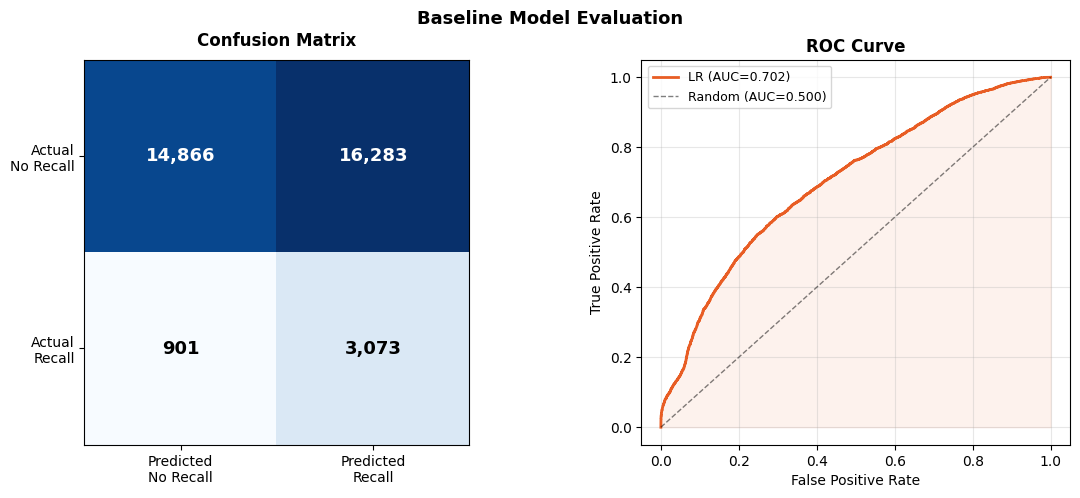

Missed recalls (False Negatives) : 901  <- want LOW
Caught recalls (True Positives)  : 3,073  <- want HIGH


In [5]:
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

ax1.imshow(cm, cmap="Blues")
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Predicted\nNo Recall", "Predicted\nRecall"])
ax1.set_yticklabels(["Actual\nNo Recall", "Actual\nRecall"])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                 fontsize=13, fontweight="bold",
                 color="white" if cm[i,j] > cm.max()/2 else "black")
ax1.set_title("Confusion Matrix", fontweight="bold", pad=10)

ax2 = fig.add_subplot(gs[1])
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, color="#E85D24", linewidth=2, label=f"LR (AUC={roc_auc:.3f})")
ax2.plot([0,1],[0,1],"k--", linewidth=1, label="Random (AUC=0.500)", alpha=0.5)
ax2.fill_between(fpr, tpr, alpha=0.08, color="#E85D24")
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve", fontweight="bold"); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle("Baseline Model Evaluation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/models/baseline_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Missed recalls (False Negatives) : {fn:,}  <- want LOW")
print(f"Caught recalls (True Positives)  : {tp:,}  <- want HIGH")

## 4. Top Predictive Words

Logistic Regression is interpretable — each word has a coefficient. Positive = pushes toward recall. Negative = pushes away. This is a unique advantage over black-box models.

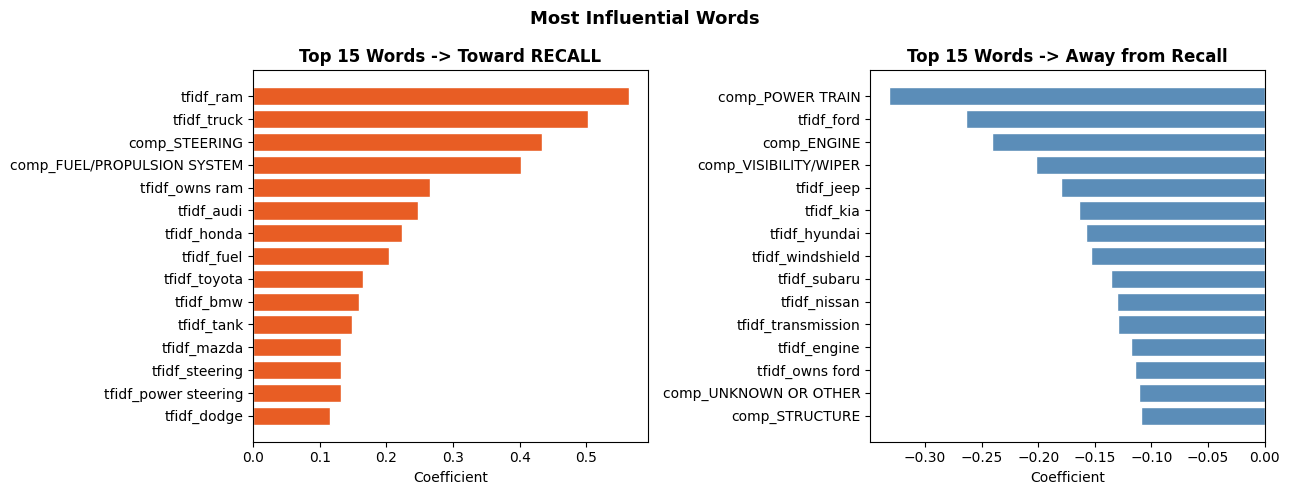

In [6]:
feature_names = load("feature_names.pkl")
coef = model.coef_[0]

top_idx    = np.argsort(coef)[-15:][::-1]
top_words  = [feature_names[i] for i in top_idx]
top_scores = coef[top_idx]
bot_idx    = np.argsort(coef)[:15]
bot_words  = [feature_names[i] for i in bot_idx]
bot_scores = coef[bot_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.barh(range(15), top_scores, color="#E85D24", edgecolor="white")
ax1.set_yticks(range(15)); ax1.set_yticklabels(top_words, fontsize=10)
ax1.set_title("Top 15 Words -> Toward RECALL", fontweight="bold")
ax1.set_xlabel("Coefficient"); ax1.invert_yaxis()

ax2.barh(range(15), bot_scores, color="#5B8DB8", edgecolor="white")
ax2.set_yticks(range(15)); ax2.set_yticklabels(bot_words, fontsize=10)
ax2.set_title("Top 15 Words -> Away from Recall", fontweight="bold")
ax2.set_xlabel("Coefficient"); ax2.invert_yaxis()

plt.suptitle("Most Influential Words", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/models/baseline_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Save Model

In [8]:
model_path = "../data/models/logistic_regression.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Saved: {model_path}")

print()
print("=" * 50)
print("  BASELINE PERFORMANCE SUMMARY")
print("=" * 50)
print(f"  Model     : Logistic Regression (balanced)")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%  <- we have to beat this by training better models")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  Missed recalls : {fn:,} / {fn+tp:,}")
print("=" * 50)

Saved: ../data/models/logistic_regression.pkl

  BASELINE PERFORMANCE SUMMARY
  Model     : Logistic Regression (balanced)
  Accuracy  : 51.07%
  Precision : 15.88%
  Recall    : 77.33%
  F1 Score  : 26.34%  <- we have to beat this by training better models
  ROC-AUC   : 0.7022
  Missed recalls : 901 / 3,974
